# Assignment 2: Industry Competition in Seattle

**Author:** Shanmukh Upadhyayula

**Date:** 21 March 2026

**Overview:** In this assignment, I analyze spatial point patterns of industries across Seattle from 1998 to 2001 from the GeoDa "Industry Competition in Seattle (2000)" dataset. I wrangle the data by converting the ZIP code attribute to centroids and visualizing the industry distribution and visualizing various statistical measures such as the mean center, standard deviational ellipse, or convex hull.

In [39]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from pointpats import centrography
import seaborn as sns
from matplotlib.patches import Ellipse
import libpysal

## Data Description, Loading, & Inspection

**Source:** GeoDa- https://geodacenter.github.io/data-and-lab/seattle2/

**Why Chosen:** I have selected this dataset because it is interesting to see how economic activity clusters together in a city. Additionally, in GGIS 379, everyone is assigned a state to analyze throughout the course, and I chose Washington so it is nice to continue that analysis here in GGIS 371.

**Dataset file type:** I have selected to use GeoJSON as it is easier to work with than shapefiles and it is spatial data unlike a csv file.

**CRS:** The default CRS is EPSG: 4326 but I have changed it to EPSG: 6596 since it is projected to Seattle instead of remaining unprojected.


In [3]:
seattle_industries = gpd.read_file("..\Data\Assignment2Data\SeattleMSA2\SeattleMSA2.geojson")

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\shanm\AppData\Local\Temp\ipykernel_11792\3487072090.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  seattle_industries = gpd.read_file("..\Data\Assignment2Data\SeattleMSA2\SeattleMSA2.geojson")


In [4]:
seattle_industries.shape

(145, 56)

In [5]:
seattle_industries.head()

,ZIP,PO_NAME,STATE,POP2001,MSA,EST98,EMP98,PAY98,EST01,EMP01,...,INFOUS01_1,INFOUS01_3,INDEX,NUMSEC,PCTNGE,PCTIME,PCTCSE,PCTGRO,ID,geometry
0,98241,DARRINGTON,WA,1940,Seattle,40,468,13299,41,455,...,89935,47358,659,13,2.21,-1.25,-7.78,-6.82,0,"MULTIPOLYGON (((-120.90621 48.16385, -120.9615..."
1,98223,ARLINGTON,WA,36244,Seattle,810,9353,259006,837,8722,...,89935,47358,657,21,2.21,-0.37,0.35,2.20,1,"MULTIPOLYGON (((-122.11132 48.07199, -122.1118..."
2,98292,STANWOOD,WA,17897,Seattle,621,3871,84210,483,3473,...,89935,47358,669,19,2.21,-0.06,8.32,10.47,2,"MULTIPOLYGON (((-122.26554 48.13928, -122.2664..."
3,98252,GRANITE FALLS,WA,7023,Seattle,108,533,11931,120,673,...,89935,47358,661,19,2.21,-0.29,3.34,5.26,3,"MULTIPOLYGON (((-121.45158 47.9686, -121.45141..."
4,98271,MARYSVILLE,WA,23362,Seattle,253,3591,106708,311,4431,...,89935,47358,664,19,2.21,-1.10,13.65,14.76,4,"MULTIPOLYGON (((-122.18372 48.03679, -122.1837..."


In [6]:
seattle_industries.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
seattle_industries = seattle_industries.to_crs(epsg=6596)
seattle_industries.crs

<Projected CRS: EPSG:6596>
Name: NAD83(2011) / Washington North
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Washington - counties of Chelan; Clallam; Douglas; Ferry; Grant north of approximately 47°30'N; Island; Jefferson; King; Kitsap; Lincoln; Okanogan; Pend Oreille; San Juan; Skagit; Snohomish; Spokane; Stevens; Whatcom.
- bounds: (-124.79, 47.08, -117.02, 49.05)
Coordinate Operation:
- name: SPCS83 Washington North zone (meter)
- method: Lambert Conic Conformal (2SP)
Datum: NAD83 (National Spatial Reference System 2011)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## Point Data Visualization

**Centroid Creation:** Since the dataset contains ZIP code polygons, they are converted to points by extracting 
the centroid of each polygon. The x and y coordinates are then extracted for use in 
the centrography functions later.

**Clustering Analysis:** The points are clearly clustered around Seattle's CBD area. This makes sense since this dataset is about industries in seattle and the CBD stands for the central business district. There is also some clustering around Everett and Tacoma. The points slowly become more and more dispersed towards the city outskirts and then extremely spread out in the rest of the state. This is why the points show a mainly clustered pattern instead of a random or uniform pattern.

In [8]:
seattle_centroids = seattle_industries.copy()
seattle_centroids["geometry"] = seattle_industries.geometry.centroid
seattle_centroids["x"] = seattle_centroids.geometry.x
seattle_centroids["y"] = seattle_centroids.geometry.y
seattle_centroids[["x", "y"]].describe()

,x,y
count,145.000000,145.000000
mean,395175.042455,56084.276914
std,18561.113588,33691.378255
min,360893.666374,-25823.551023
25%,384616.106069,28878.424149
50%,390377.111581,60972.434598
75%,402213.553430,77258.400181
max,465819.398964,136737.595714


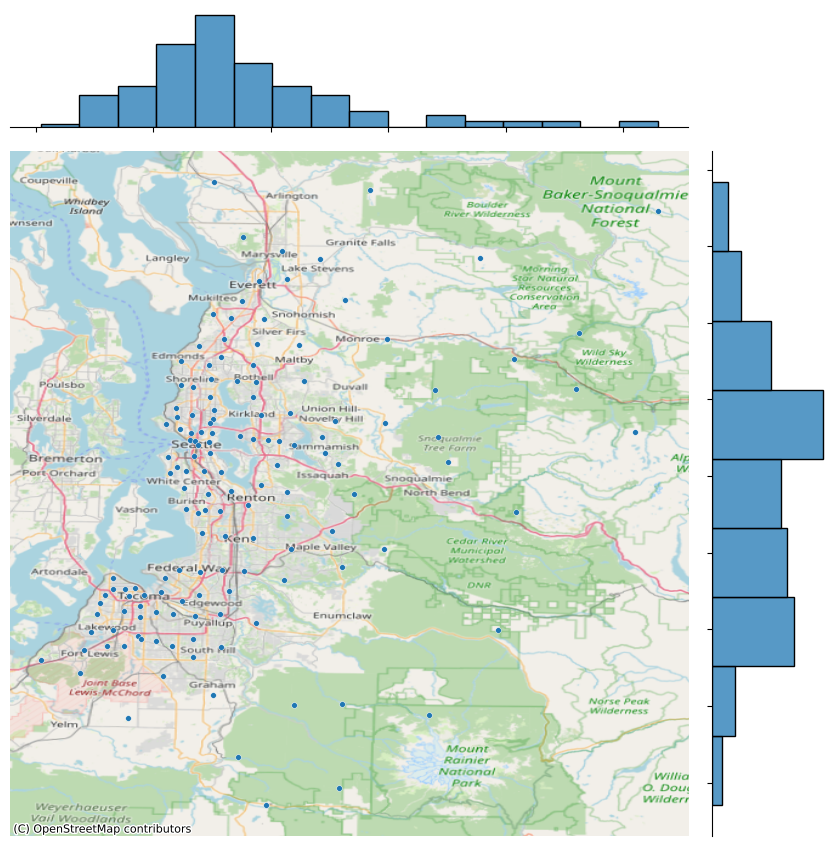

In [35]:
joint_axes = sns.jointplot(
    x="x", y="y", data=seattle_centroids, s=17, height=9
)
ctx.add_basemap(
    joint_axes.ax_joint,
    crs=seattle_centroids.crs.to_string(),
    source=ctx.providers.OpenStreetMap.Mapnik
)
joint_axes.ax_joint.set_axis_off()

## Point Data Centrography

The following centrography measures are computed using the the pointpats library. The code for the maps is modeled after the Ch8.2Centrography-3 lab.

**Mean Center:** The mean center falls near Renton, which is just south of Seattle. This indicates 
center is just slightly south of the actual Seattle CBD. This reflects the second highest concentration of points being in Tacoma.

**Standard Deviational Ellipse:** The standard deviational ellipse is oriented from southwest to northeast, 
covering the entire Seattle metropolitan area. In other words, it encompasses mainly the urban 
and suburban areas (beige on the basemap) and barely extends into the forested and 
mountainous regions (green on the basemap). This reaffirms the map from the point data visualzation that showed industry establishments concentrated in developed areas.

**Convex Hull:** The convex hull extends across nearly the entire map extent, that the extent of the points is also very vast.

In [45]:
mean_center = centrography.mean_center(seattle_centroids[["x", "y"]])
major, minor, rotation = centrography.ellipse(seattle_centroids[["x", "y"]])
std_distance = centrography.std_distance(seattle_centroids[["x", "y"]])
coordinates = seattle_centroids[["x", "y"]].values
convex_hull_vertices = centrography.hull(coordinates)
alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(
    coordinates, return_circles=True
)

print("mean center:", mean_center)
print("std distance:", std_distance)
print("major:", major, "minor:", minor, "rotation:", rotation)

mean center: [395175.04245484  56084.27691377]
std distance: 38333.00932047795
major: 49129.99110613734 minor: 23794.659638081368 rotation: 1.3048069406762552


C:\Users\shanm\AppData\Local\Temp\ipykernel_11792\3281398182.py:6: UserWarning: Numba not imported, so alpha shape construction may be slower than expected.
  alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(


C:\Users\shanm\AppData\Local\Temp\ipykernel_11792\2827122635.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[2].legend()


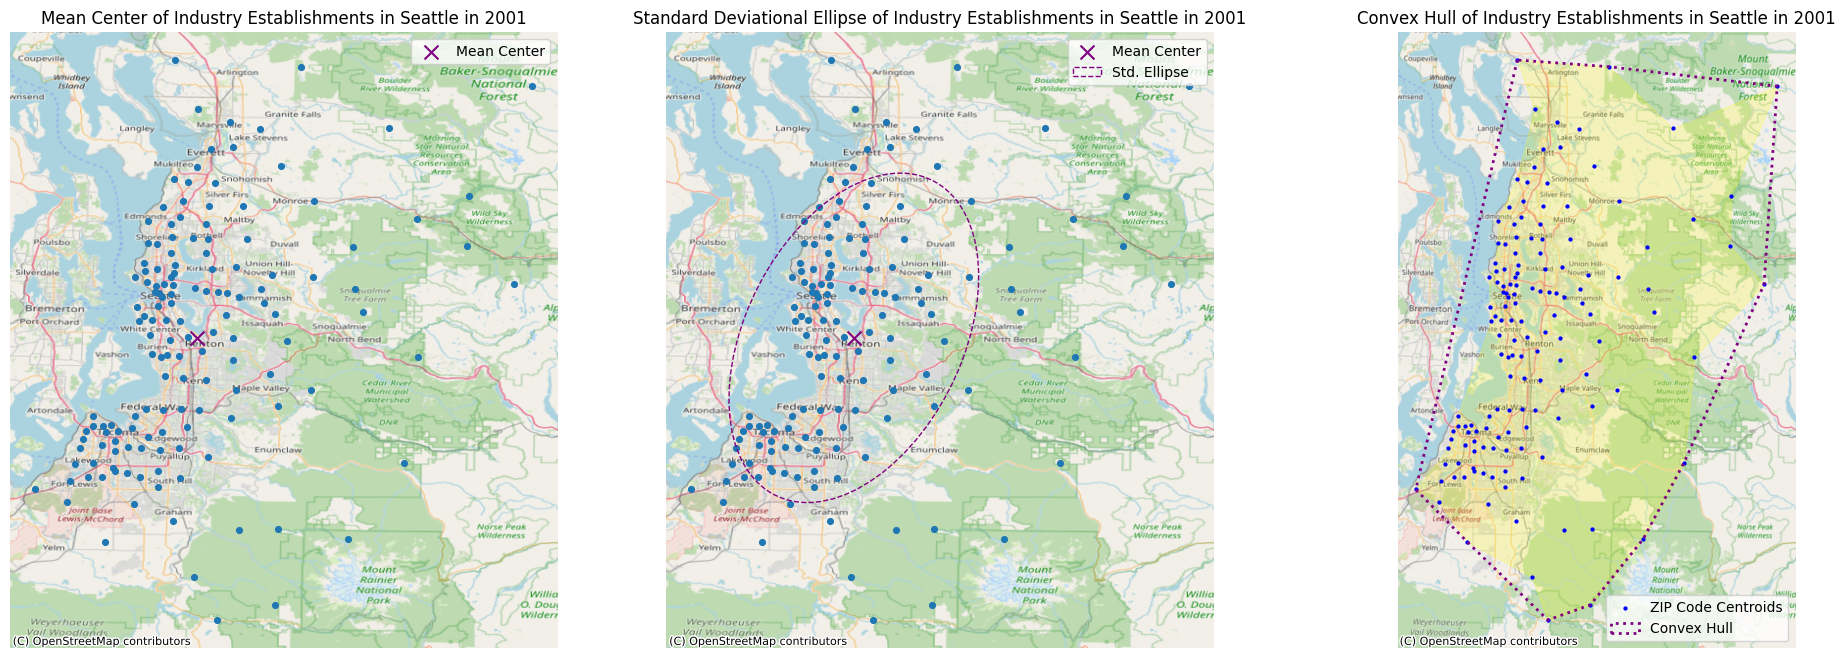

In [44]:
f, axes = plt.subplots(1, 3, figsize=(24, 8))

# Mean Center
axes[0].scatter(seattle_centroids["x"], seattle_centroids["y"], s=17)
axes[0].scatter(*mean_center, color="purple", marker="x", s=100, label="Mean Center")
axes[0].legend()
axes[0].set_title("Mean Center of Industry Establishments in Seattle in 2001")
axes[0].set_axis_off()
ctx.add_basemap(axes[0], crs=seattle_centroids.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Standard Deviational Ellipse
axes[1].scatter(seattle_centroids["x"], seattle_centroids["y"], s=17)
axes[1].scatter(*mean_center, color="purple", marker="x", s=100, label="Mean Center")
ellipse = Ellipse(
    xy=mean_center, width=major * 2, height=minor * 2,
    angle=np.rad2deg(rotation), facecolor="none",
    edgecolor="purple", linestyle="--", label="Std. Ellipse"
)
axes[1].add_patch(ellipse)
axes[1].legend()
axes[1].set_title("Standard Deviational Ellipse of Industry Establishments in Seattle in 2001")
axes[1].set_axis_off()
ctx.add_basemap(axes[1], crs=seattle_centroids.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Convex Hull
gpd.GeoSeries([alpha_shape]).plot(
    ax=axes[2],
    edgecolor="yellow",
    facecolor="yellow",
    alpha=0.2,
    label="Alpha Shape"
)
axes[2].scatter(*coordinates.T, color="blue", marker=".", s=17, label="ZIP Code Centroids")
axes[2].add_patch(plt.Polygon(
    convex_hull_vertices, closed=True, edgecolor="purple",
    facecolor="none", linestyle=":", linewidth=2, label="Convex Hull"
))
axes[2].legend()
axes[2].set_title("Convex Hull of Industry Establishments in Seattle in 2001")
axes[2].set_axis_off()
ctx.add_basemap(axes[2], crs=seattle_centroids.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

## Bonus: Industry Shift Analysis

As a bonus spatial analysis, an industry shift analysis is performed by seeing the growth or decline in industries from 1998 to 2001.

The two attributes beign visualized are (I used Claude to do the visualizations):

**Industry Mix Effect (PCTIME):** Measures whether a ZIP code's growth is attributed 
to having a favorable mix of industries. Blue ZIP codes benefit from being 
concentrated in industries that were growing nationally. Red ZIP codes are 
concentrated in industries that were declining.

**Competitive Shift Effect (PCTCSE):** Measures whether a ZIP code's growth is due 
to local competitiveness rather than national or industry trends. Blue ZIP codes outperformed what would be expected given nationally and 
red ZIP codes underperformed what would be given nationally.

**Spatial Clustering:** Spatial Clustering is present because the favorable industry mix and competitiveness in the CBD confirms that the industries grow in a CBD

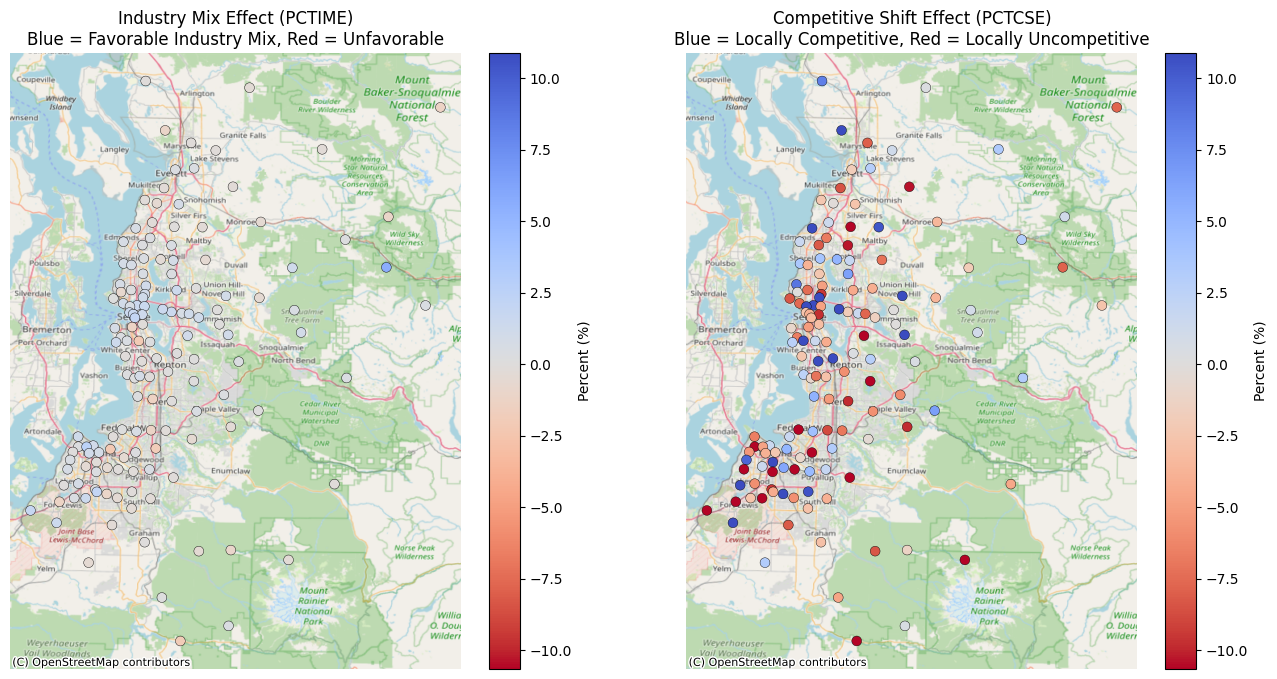

In [54]:
f, axes = plt.subplots(1, 2, figsize=(16, 8))

all_vals = pd.concat([seattle_centroids["PCTIME"], seattle_centroids["PCTCSE"]])
vmin = all_vals.quantile(0.05)
vmax = all_vals.quantile(0.95)

for ax, col, title in zip(axes,
    ["PCTIME", "PCTCSE"],
    ["Industry Mix Effect (PCTIME)\nBlue = Favorable Industry Mix, Red = Unfavorable",
     "Competitive Shift Effect (PCTCSE)\nBlue = Locally Competitive, Red = Locally Uncompetitive"]
):
    scatter = ax.scatter(
        seattle_centroids["x"], seattle_centroids["y"],
        c=seattle_centroids[col],
        cmap="coolwarm_r", s=50, edgecolors="k", linewidths=0.3,
        vmin=vmin, vmax=vmax
    )
    plt.colorbar(scatter, ax=ax, label="Percent (%)")
    ctx.add_basemap(ax, crs=seattle_centroids.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_title(title)
    ax.set_axis_off()
